# Exploratory Data Analysis (EDA) – E-Commerce Sales Dataset

**Project:** DecodeLabs Project 2  
**Objective:** Analyze the cleaned sales dataset to identify patterns, trends, distributions, and outliers.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Chart display settings
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

In [3]:
# File path: notebook is inside /notebooks, while dataset is inside /data
file_path = Path("../data/Dataset_refined.xlsx")

try:
    df = pd.read_excel(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("File not found. Check that Dataset_refined.xlsx is inside the data folder.")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset loaded successfully!


In [4]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.6,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.1
1,ORD200001,2024-08-23,C75739,Phone,2,151.4,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.7
2,ORD200002,2024-02-27,C81728,Tablet,5,550.7,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.4
3,ORD200003,2023-10-15,C33540,Chair,1,273.2,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.2
4,ORD200004,2025-05-08,C81840,Printer,4,626.0,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.0


In [5]:
print("Dataset Shape:", df.shape)
print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types and Non-Null Values:")
df.info()

Dataset Shape: (1200, 14)

Number of Rows: 1200
Number of Columns: 14

Column Names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data Types and Non-Null Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object 

In [6]:
print("Missing Values in Each Column:")
display(df.isnull().sum())

print("\nTotal Duplicate Rows:", df.duplicated().sum())

Missing Values in Each Column:


OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


Total Duplicate Rows: 0


## Initial Dataset Observation

- The dataset contains **1,200 sales records** and **14 columns**.
- It includes transaction, product, pricing, payment, order-status, coupon, and referral-source information.
- No missing values or duplicate records were found after data cleaning.
- Therefore, the dataset is ready for exploratory analysis.

In [7]:
df.columns.tolist()

['OrderID',
 'Date',
 'CustomerID',
 'Product',
 'Quantity',
 'UnitPrice',
 'ShippingAddress',
 'PaymentMethod',
 'OrderStatus',
 'TrackingNumber',
 'ItemsInCart',
 'CouponCode',
 'ReferralSource',
 'TotalPrice']

In [8]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Date column converted successfully.")
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Invalid dates:", df["Date"].isnull().sum())

Date column converted successfully.
Date range: 2023-01-01 to 2025-06-30
Invalid dates: 0


In [9]:
numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

summary_stats = df[numeric_cols].agg(
    ["count", "mean", "median", "min", "max", "std"]
).T.round(2)

summary_stats

,count,mean,median,min,max,std
Quantity,1200.0,2.95,3.0,1.0,5.0,1.41
UnitPrice,1200.0,356.41,364.2,11.4,699.9,197.18
ItemsInCart,1200.0,5.48,5.0,1.0,10.0,2.28
TotalPrice,1200.0,1053.97,823.6,11.4,3456.4,819.86


In [10]:
total_orders = df["OrderID"].nunique()
total_revenue = df["TotalPrice"].sum()
average_order_value = df["TotalPrice"].mean()
median_order_value = df["TotalPrice"].median()
unique_customers = df["CustomerID"].nunique()

print(f"Total Orders: {total_orders}")
print(f"Unique Customers: {unique_customers}")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Median Order Value: ₹{median_order_value:,.2f}")

Total Orders: 1200
Unique Customers: 1189
Total Revenue: ₹1,264,761.50
Average Order Value: ₹1,053.97
Median Order Value: ₹823.60


In [11]:
categorical_cols = [
    "Product",
    "PaymentMethod",
    "OrderStatus",
    "CouponCode",
    "ReferralSource"
]

for col in categorical_cols:
    print(f"\n--- {col} Distribution ---")
    display(df[col].value_counts())


--- Product Distribution ---


Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


--- PaymentMethod Distribution ---


PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


--- OrderStatus Distribution ---


OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


--- CouponCode Distribution ---


CouponCode
FREESHIP       313
Not Applied    309
WINTER15       292
SAVE10         286
Name: count, dtype: int64


--- ReferralSource Distribution ---


ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

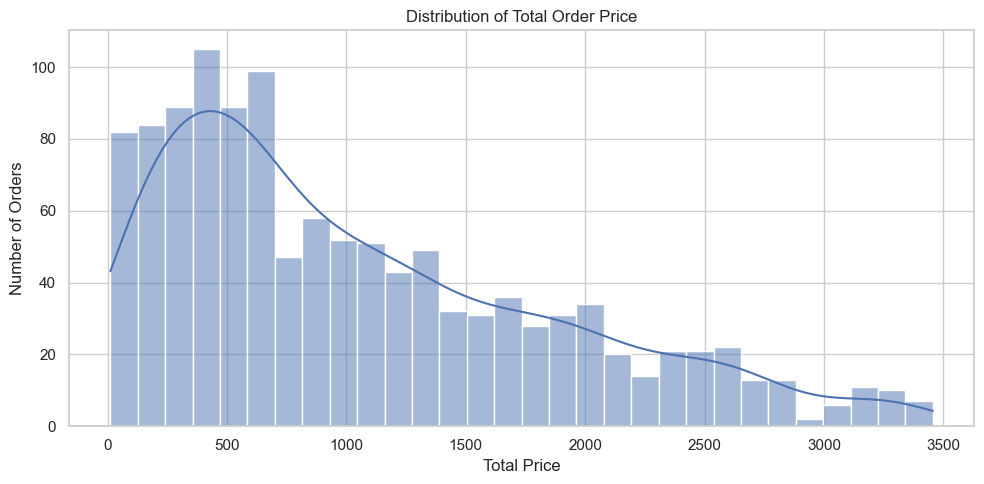

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="TotalPrice", bins=30, kde=True)

plt.title("Distribution of Total Order Price")
plt.xlabel("Total Price")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig("../visuals/total_price_distribution.png", dpi=300)
plt.show()

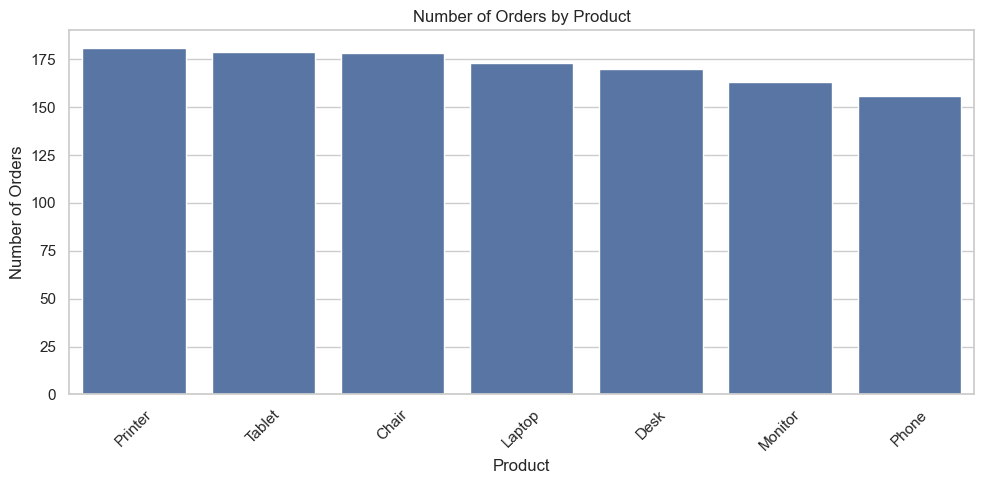

In [13]:
product_order_count = (
    df["Product"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=product_order_count.index,
    y=product_order_count.values
)

plt.title("Number of Orders by Product")
plt.xlabel("Product")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visuals/product_order_count.png", dpi=300)
plt.show()

## Descriptive Statistics Observation

- The dataset contains **1,200 orders** from **1,189 unique customers**, indicating that most customers placed only one order.
- Total revenue generated is **₹1,264,761.50**.
- The average order value is **₹1,053.97**, while the median order value is lower at **₹823.60**.
- Since the mean order value is higher than the median, the Total Price distribution is likely **right-skewed** due to a small number of high-value orders.
- These high-value transactions may have a noticeable effect on overall revenue and should be examined further through outlier analysis.
- Product-order analysis identifies which products are purchased most frequently and can support inventory planning.

,Total Revenue
Product,
Chair,195620.3
Printer,195612.4
Laptop,192126.1
Tablet,186568.8
Monitor,175652.1
Desk,167459.5
Phone,151722.3


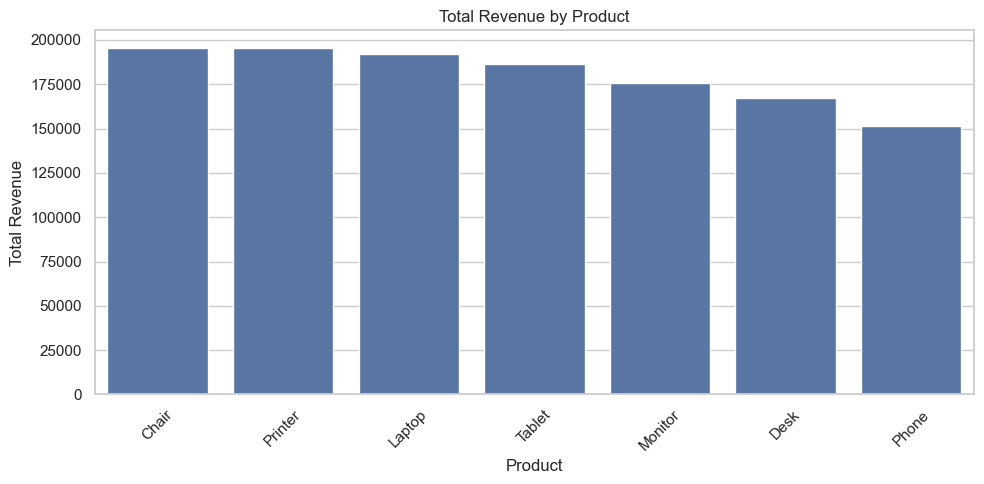

In [14]:
product_revenue = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

display(product_revenue.to_frame(name="Total Revenue"))

plt.figure(figsize=(10, 5))
sns.barplot(x=product_revenue.index, y=product_revenue.values)

plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visuals/product_wise_revenue.png", dpi=300)
plt.show()

,Average Order Value
Product,
Laptop,1110.555491
Chair,1098.990449
Printer,1080.731492
Monitor,1077.620245
Tablet,1042.283799
Desk,985.055882
Phone,972.578846


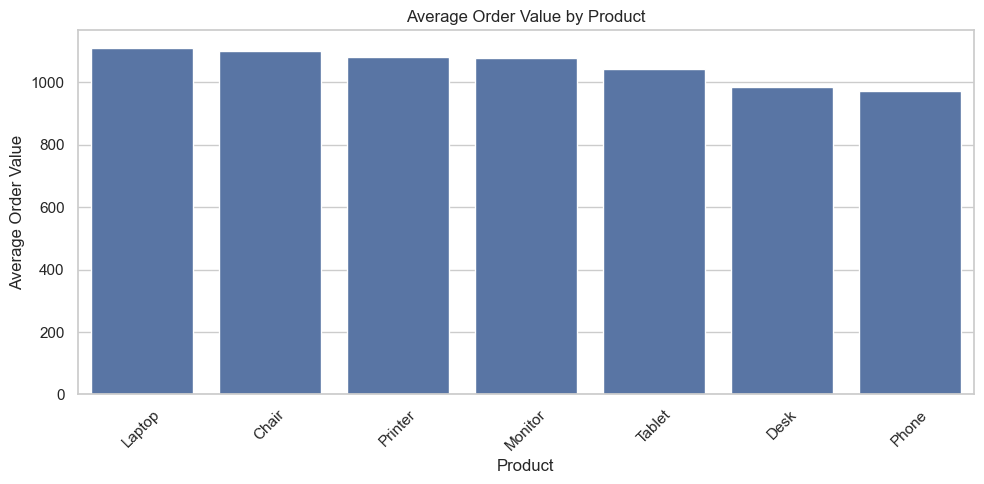

In [15]:
avg_order_by_product = (
    df.groupby("Product")["TotalPrice"]
    .mean()
    .sort_values(ascending=False)
)

display(avg_order_by_product.to_frame(name="Average Order Value"))

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_order_by_product.index, y=avg_order_by_product.values)

plt.title("Average Order Value by Product")
plt.xlabel("Product")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visuals/average_order_value_by_product.png", dpi=300)
plt.show()

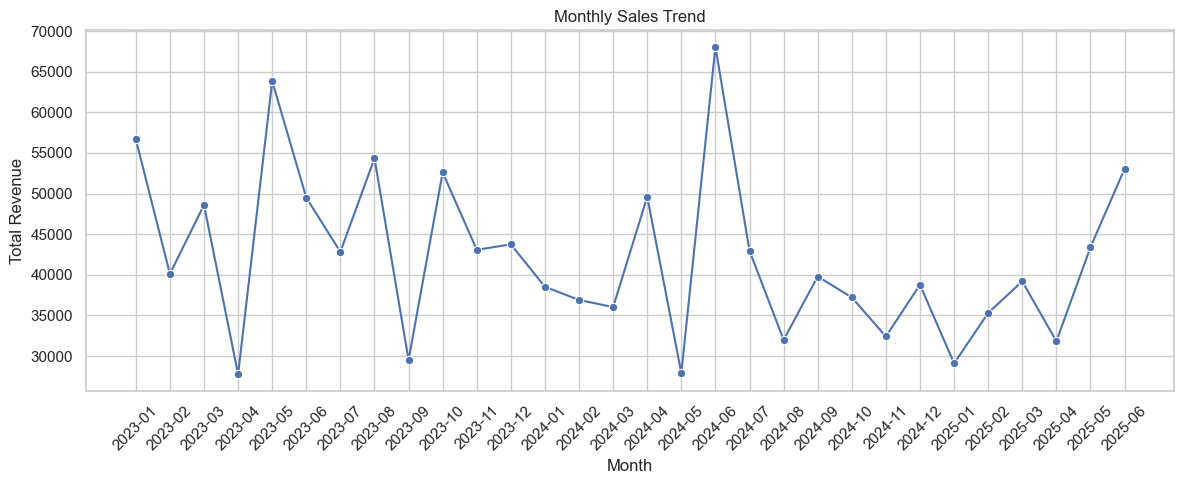

In [16]:
df["YearMonth"] = df["Date"].dt.to_period("M")

monthly_sales = (
    df.groupby("YearMonth")["TotalPrice"]
    .sum()
    .reset_index()
)

monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="YearMonth", y="TotalPrice", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visuals/monthly_sales_trend.png", dpi=300)
plt.show()

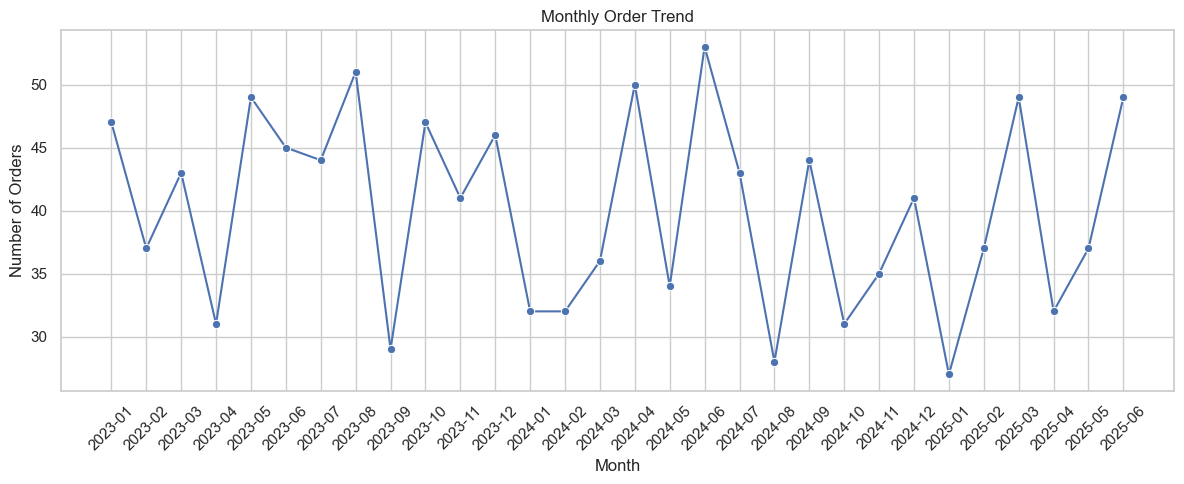

In [17]:
monthly_orders = (
    df.groupby("YearMonth")["OrderID"]
    .nunique()
    .reset_index(name="OrderCount")
)

monthly_orders["YearMonth"] = monthly_orders["YearMonth"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_orders, x="YearMonth", y="OrderCount", marker="o")

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visuals/monthly_order_trend.png", dpi=300)
plt.show()

In [18]:
status_summary = (
    df.groupby("OrderStatus")
    .agg(
        Orders=("OrderID", "nunique"),
        GrossOrderValue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values("Orders", ascending=False)
    .round(2)
)

status_summary

,Orders,GrossOrderValue,AverageOrderValue
OrderStatus,,,
Cancelled,250,276396.5,1105.59
Returned,247,243277.2,984.93
Pending,237,256328.3,1081.55
Shipped,235,246159.3,1047.49
Delivered,231,242600.2,1050.22


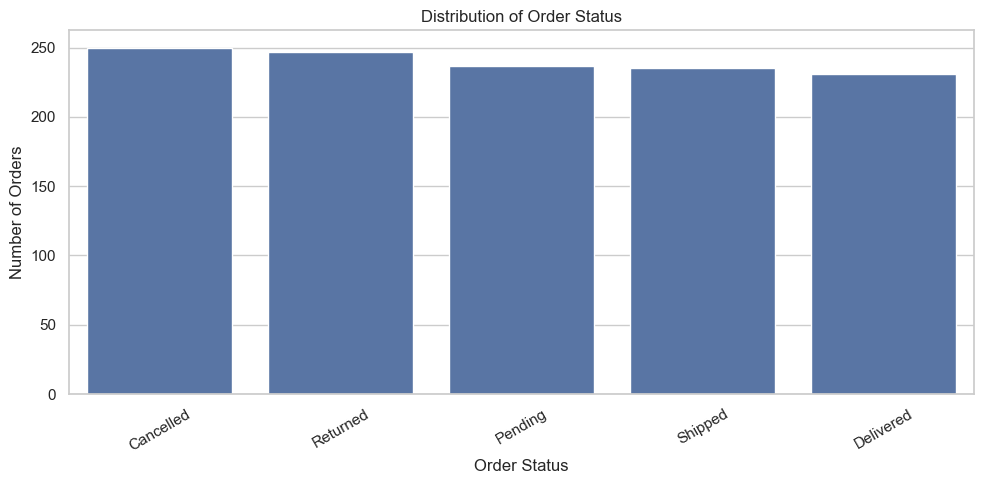

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="OrderStatus",
    order=df["OrderStatus"].value_counts().index
)

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("../visuals/order_status_distribution.png", dpi=300)
plt.show()

In [20]:
payment_summary = (
    df.groupby("PaymentMethod")
    .agg(
        Orders=("OrderID", "nunique"),
        GrossOrderValue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values("GrossOrderValue", ascending=False)
    .round(2)
)

payment_summary

,Orders,GrossOrderValue,AverageOrderValue
PaymentMethod,,,
Credit Card,234,263847.7,1127.55
Online,258,262442.7,1017.22
Cash,246,259786.0,1056.04
Gift Card,230,246323.8,1070.97
Debit Card,232,232361.3,1001.56


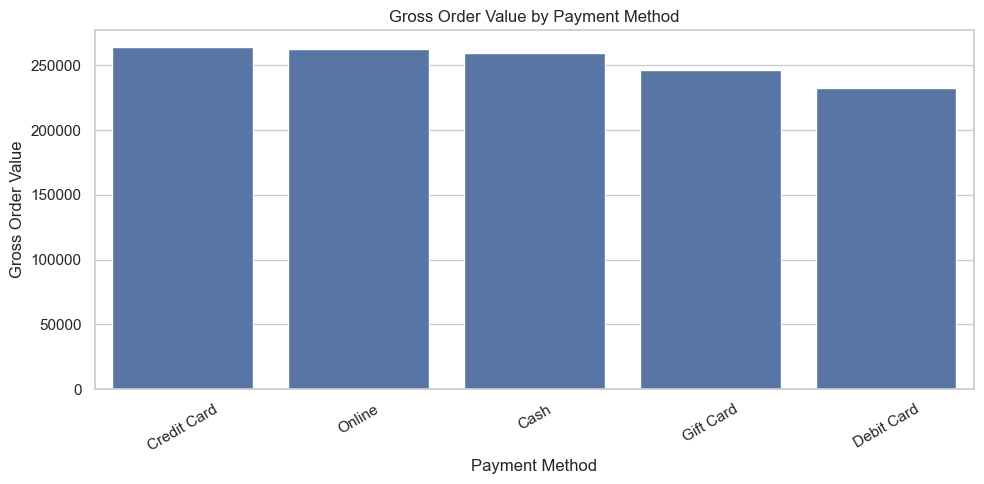

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=payment_summary.reset_index(),
    x="PaymentMethod",
    y="GrossOrderValue"
)

plt.title("Gross Order Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Gross Order Value")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("../visuals/payment_method_revenue.png", dpi=300)
plt.show()

In [22]:
coupon_summary = (
    df.groupby("CouponCode")
    .agg(
        Orders=("OrderID", "nunique"),
        GrossOrderValue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values("GrossOrderValue", ascending=False)
    .round(2)
)

coupon_summary

,Orders,GrossOrderValue,AverageOrderValue
CouponCode,,,
FREESHIP,313,335036.9,1070.41
Not Applied,309,322401.8,1043.37
SAVE10,286,304839.7,1065.87
WINTER15,292,302483.1,1035.90


In [23]:
referral_summary = (
    df.groupby("ReferralSource")
    .agg(
        Orders=("OrderID", "nunique"),
        GrossOrderValue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values("GrossOrderValue", ascending=False)
    .round(2)
)

referral_summary

,Orders,GrossOrderValue,AverageOrderValue
ReferralSource,,,
Instagram,259,275285.4,1062.88
Email,250,261808.5,1047.23
Google,241,250441.4,1039.18
Facebook,228,250410.1,1098.29
Referral,222,226816.1,1021.69


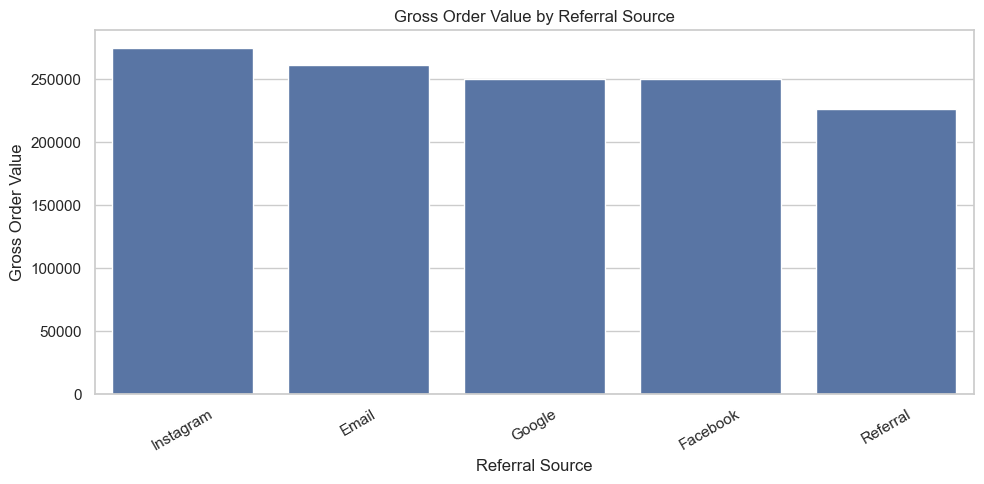

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=referral_summary.reset_index(),
    x="ReferralSource",
    y="GrossOrderValue"
)

plt.title("Gross Order Value by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Gross Order Value")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("../visuals/referral_source_revenue.png", dpi=300)
plt.show()

## Product and Trend Analysis Observation

- **Chair** generated the highest gross order value at **₹195,620.30**, but it was almost tied with **Printer** at **₹195,612.40**.
- **Laptop** recorded the highest average order value at approximately **₹1,110.56**.
- **June 2024** was the strongest month, generating gross order value of **₹68,068.80** from **53 orders**.
- Since the highest-sales month also had the highest number of orders, order volume appears to have contributed strongly to monthly sales performance.

## Marketing and Order Behaviour Observation

- **Online payment** was the most frequently used method, while **Credit Card** generated the highest gross order value.
- **FREESHIP** was the most-used coupon code and generated the highest gross order value among coupon categories.
- **Instagram** generated the highest gross order value among referral sources, indicating strong potential as a customer-acquisition channel.
- Cancelled and returned orders together account for a substantial share of transactions. Therefore, the overall ₹1,264,761.50 should be interpreted as **gross order value**, not necessarily final realized revenue.

In [25]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

totalprice_outliers = df[
    (df["TotalPrice"] < lower_limit) |
    (df["TotalPrice"] > upper_limit)
]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Limit: {lower_limit:.2f}")
print(f"Upper Limit: {upper_limit:.2f}")
print(f"Number of TotalPrice Outliers: {len(totalprice_outliers)}")

display(
    totalprice_outliers[
        ["OrderID", "Date", "Product", "Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
    ].sort_values("TotalPrice", ascending=False)
)

Q1: 410.50
Q3: 1578.45
IQR: 1167.95
Lower Limit: -1341.43
Upper Limit: 3330.38
Number of TotalPrice Outliers: 8


,OrderID,Date,Product,Quantity,UnitPrice,ItemsInCart,TotalPrice
789,ORD200789,2023-08-17,Tablet,5,691.3,10,3456.4
1122,ORD201122,2023-06-07,Monitor,5,678.2,8,3391.0
632,ORD200632,2023-05-02,Laptop,5,678.2,7,3390.8
469,ORD200469,2023-11-26,Chair,5,677.0,5,3384.9
328,ORD200328,2023-02-28,Tablet,5,674.0,7,3370.2
107,ORD200107,2023-03-27,Printer,5,670.8,8,3353.8
326,ORD200326,2024-07-01,Laptop,5,670.5,5,3352.4
1065,ORD201065,2023-10-30,Printer,5,666.8,7,3334.0


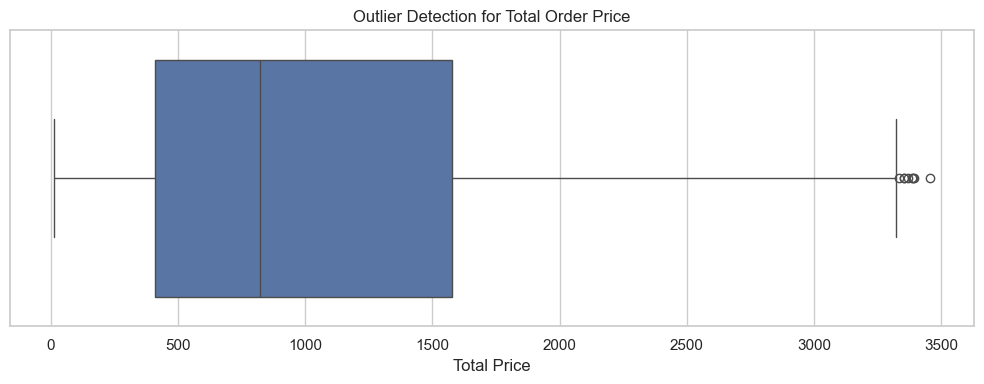

In [26]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["TotalPrice"])

plt.title("Outlier Detection for Total Order Price")
plt.xlabel("Total Price")
plt.tight_layout()

plt.savefig("../visuals/total_price_boxplot.png", dpi=300)
plt.show()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.00,0.01,0.65,0.62
UnitPrice,0.01,1.00,0.00,0.72
ItemsInCart,0.65,0.00,1.00,0.39
TotalPrice,0.62,0.72,0.39,1.00


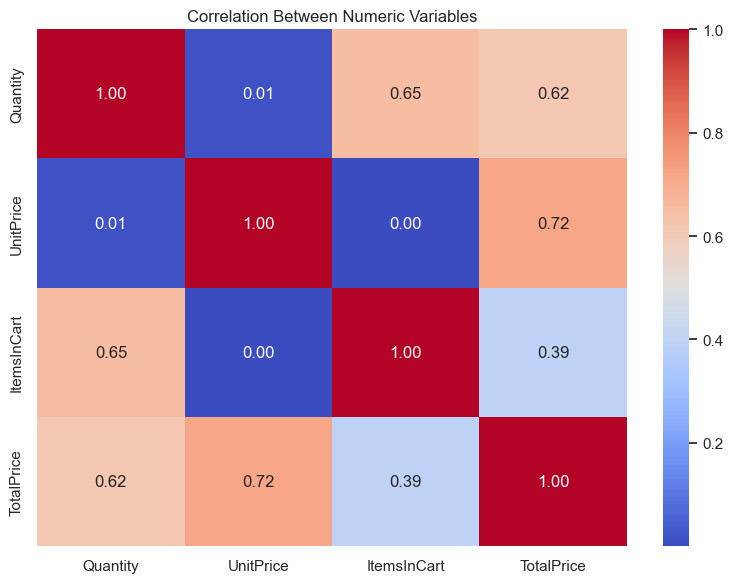

In [27]:
numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

correlation_matrix = df[numeric_cols].corr()

display(correlation_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numeric Variables")
plt.tight_layout()

plt.savefig("../visuals/correlation_heatmap.png", dpi=300)
plt.show()

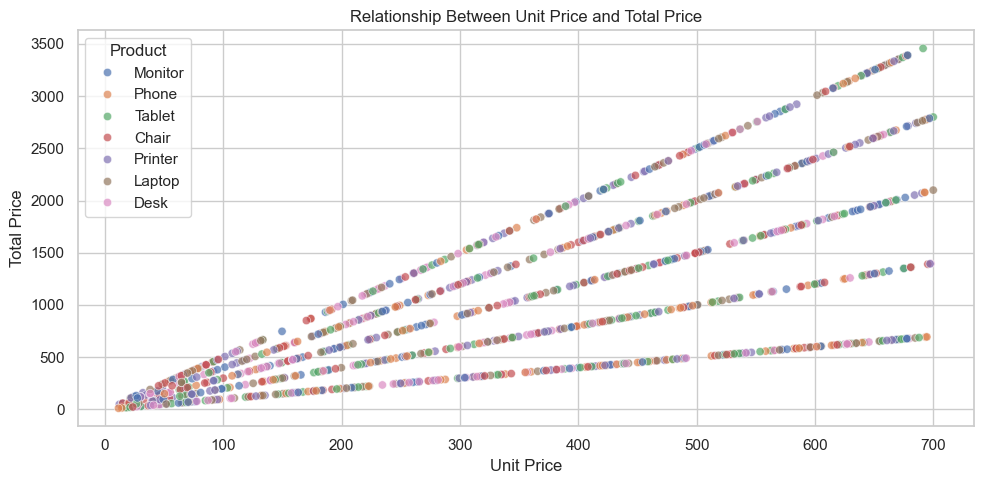

In [28]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="UnitPrice",
    y="TotalPrice",
    hue="Product",
    alpha=0.7
)

plt.title("Relationship Between Unit Price and Total Price")
plt.xlabel("Unit Price")
plt.ylabel("Total Price")
plt.tight_layout()

plt.savefig("../visuals/unitprice_vs_totalprice.png", dpi=300)
plt.show()

# Key Insights and Conclusion

1. The dataset contains **1,200 orders** from **1,189 unique customers**. Most customers placed only one order, suggesting limited repeat-order behaviour in this dataset.

2. The dataset generated a gross order value of **₹1,264,761.50**. The mean order value (**₹1,053.97**) is higher than the median (**₹823.60**), indicating that a small number of expensive orders increase the average.

3. **Chair** generated the highest gross order value at **₹195,620.30**, closely followed by **Printer** at **₹195,612.40**. These products are major contributors to sales performance.

4. **Laptop** had the highest average order value, suggesting that it contributes strongly to revenue despite having fewer orders than some other products.

5. **June 2024** was the strongest sales month, with gross order value of **₹68,068.80** from **53 orders**. Higher order volume appears to be a major factor behind stronger monthly performance.

6. **Credit Card** generated the highest gross order value among payment methods, while **Online** was used most frequently.

7. **FREESHIP** was the most-used coupon code and also generated the highest gross order value among coupon categories.

8. **Instagram** generated the highest gross order value among referral sources, making it a potentially valuable customer-acquisition channel.

9. The IQR method identified **8 high-value TotalPrice outliers** above approximately **₹3,330.38**. These appear to be large legitimate purchases rather than obvious data errors, but they should be monitored because they affect average-order-value calculations.

10. TotalPrice has a strong positive relationship with **UnitPrice** and a moderate positive relationship with **Quantity**. This means expensive products and larger purchases both contribute to higher order values.

11. Cancelled and returned orders together form about **41.4% of transactions**. Therefore, the total ₹1,264,761.50 should be treated as gross order value, not guaranteed realized revenue.